In [2]:
import pandas as pd

In [3]:
import pickle

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge


from sklearn.metrics import root_mean_squared_error

In [6]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("demo-taxi-experiment")

# List all experiments
experiments = mlflow.search_experiments()
for exp in experiments:
    print(f"Experiment: {exp.name} (ID: {exp.experiment_id})")

# List runs in your experiment
runs = mlflow.search_runs(experiment_names=["demo-taxi-experiment"])
print(runs[['run_id', 'status', 'metrics.rmse']])

Experiment: my_cool_experiment (ID: 4)
Experiment: demo-taxi-experiment (ID: 3)
Experiment: taxi-experiment (ID: 2)
Experiment: nyc-taxi-experiment (ID: 1)
Experiment: Default (ID: 0)
                              run_id    status  metrics.rmse
0   fb92db856a0942f7803191050501ecc7  FINISHED      7.995795
1   912e616841c14db39a295f23067e10f5  FINISHED      7.995795
2   dd19ee8f0a2d40138c6e4515f21b11dc  FINISHED      7.995795
3   39e54d740aca4349867953bb6da6770e  FINISHED     12.101212
4   d5c96b76f77c47568a160a19bf476914  FINISHED      6.852702
5   cc0839c6ba7c464aada024b1c02fe573  FINISHED      7.250602
6   8a88457d3e9a4b809d1e52bbdbd7cf06  FINISHED      6.893543
7   8cbae70168a64d27bb5285b392b94148  FINISHED      6.847849
8   8d83512bbd7047b6be2a7be21d19a7e7  FINISHED      6.854770
9   ba3c5d2215dd4a4a9ff94e3f6c0d06a9  FINISHED      6.901559
10  ab91bb19382d480b82a701daba990779  FINISHED      6.852051
11  b3d0dfd190fc48c8ab0269d8d4dddc05  FINISHED      7.023508
12  ba07d09340364a4997d

In [17]:
import os
print(os.getcwd())

c:\Users\AvadhootHublikar\Documents\mlops\mlops-zoomcamp\03-model_training\experiment_tracking


In [18]:
df = pd.read_parquet('./data/green_tripdata_2021-01.parquet')

df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)

df['duration'] =  df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60 )

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)
                   

In [19]:
#df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2022-01.parquet')
#df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2024-01.parquet')

train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

rmse = root_mean_squared_error(y_train, y_pred)


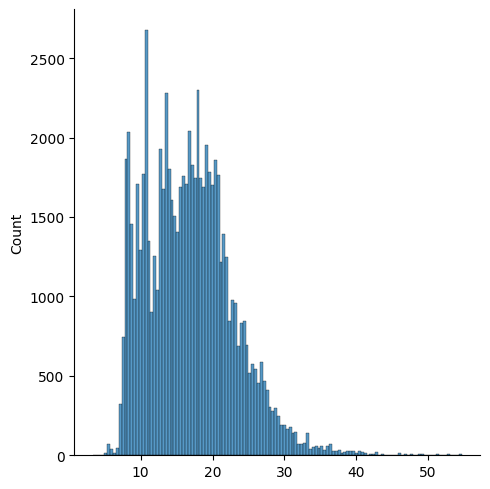

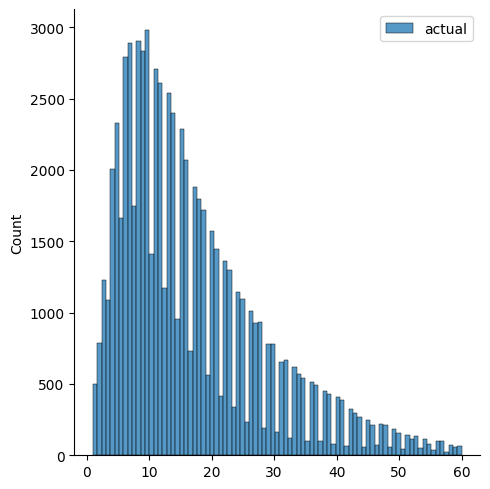

In [8]:
#len(df_train), len(df_val)
sns.displot(y_pred, label='prediction')
sns.displot(y_train, label='actual')

plt.legend()

In [20]:
def read_dataframe(filename):
    df = pd.read_parquet(filename)

    df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
    df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)

    df['duration'] =  df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60 )

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    return df

In [21]:
df_train = read_dataframe('./data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('./data/green_tripdata_2021-02.parquet')


In [22]:
len(df_train), len(df_val)

(73908, 61921)

In [23]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_train['DOLocationID']

In [24]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)


In [25]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

rmse = root_mean_squared_error(y_val, y_pred)
print(rmse)


14.950286851618925


In [27]:
with open('./models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [39]:
with mlflow.start_run():
    mlflow.set_tag("model", "Lasso")
    mlflow.set_tag("Developer", "Avadhoot")
    mlflow.log_param("train-data-path", './data/green_tripdata_2021-01.parquet')
    mlflow.log_param("val-data-path", './data/green_tripdata_2021-02.parquet')

    alpha = 0.01
    mlflow.log_param("alpha", alpha)

    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    mlflow.log_artifact(local_path='./models/lin_reg.bin', artifact_path='model_pickle')


In [13]:
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

c:\Users\AvadhootHublikar\Documents\mlops\exp-tracking\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [28]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [37]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "XGBoost")
        mlflow.set_tag("Developer", "Avadhoot")
        mlflow.log_param("max_depth", params['max_depth'])
        booster = xgb.train(
            params=params, 
            dtrain=train, 
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [38]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0), #exp(-3), exp(0) - [0.05, 1.0]
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42,
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials())

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

c:\Users\AvadhootHublikar\Documents\mlops\exp-tracking\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:45:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:9.12865                           
[1]	validation-rmse:7.78461                           
[2]	validation-rmse:7.23578                           
[3]	validation-rmse:7.01991                           
[4]	validation-rmse:6.93195                           
[5]	validation-rmse:6.89335                           
[6]	validation-rmse:6.87695                           
[7]	validation-rmse:6.86809                           
[8]	validation-rmse:6.86354                           
[9]	validation-rmse:6.86148                           
[10]	validation-rmse:6.86037                          
[11]	validation-rmse:6.86069                          
[12]	validation-rmse:6.86010                          
[13]	validation-rmse:6.85952                          
[14]	validation-rmse:6.85922                          
[15]	validation-rmse:6.85968                          
[16]	validation-rmse:6.85933                          
[17]	validation-rmse:6.85936                          
[18]	valid

c:\Users\AvadhootHublikar\Documents\mlops\exp-tracking\Lib\site-packages\xgboost\callback.py:385: UserWarning: [13:45:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:11.34523                                                   
[1]	validation-rmse:10.60662                                                   
[2]	validation-rmse:9.97866                                                    
[3]	validation-rmse:9.45104                                                    
[4]	validation-rmse:9.00632                                                    
[5]	validation-rmse:8.63705                                                    
[6]	validation-rmse:8.32856                                                    
[7]	validation-rmse:8.07472                                                    
[8]	validation-rmse:7.86630                                                    
[9]	validation-rmse:7.69436                                                    
[10]	validation-rmse:7.55220                                                   
[11]	validation-rmse:7.43395                                                   
[12]	validation-rmse:7.33890            

...

[0]	validation-rmse:11.01037                                                    
[1]	validation-rmse:10.05674                                                    
[2]	validation-rmse:9.30728                                                     
[3]	validation-rmse:8.72759                                                     
[4]	validation-rmse:8.28256                                                     
[5]	validation-rmse:7.94228                                                     
[6]	validation-rmse:7.68436                                                     
[7]	validation-rmse:7.49210                                                     
[8]	validation-rmse:7.34669                                                     
[9]	validation-rmse:7.23703                                                     
[10]	validation-rmse:7.15395                                                    
[11]	validation-rmse:7.09090                                                    
[12]	validation-rmse:7.04361

c:\Users\AvadhootHublikar\Documents\mlops\exp-tracking\Lib\site-packages\xgboost\callback.py:385: UserWarning: [14:10:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:7.73851                                                     
[1]	validation-rmse:7.09182                                                     
[2]	validation-rmse:7.00597                                                     
[3]	validation-rmse:7.02559                                                     
[4]	validation-rmse:7.03745                                                     
[5]	validation-rmse:7.03915                                                     
[6]	validation-rmse:7.04358                                                     
[7]	validation-rmse:7.04235                                                     
[8]	validation-rmse:7.04548                                                     
[9]	validation-rmse:7.05488                                                     
[10]	validation-rmse:7.05669                                                    
[11]	validation-rmse:7.06419                                                    
[12]	validation-rmse:7.07023

c:\Users\AvadhootHublikar\Documents\mlops\exp-tracking\Lib\site-packages\xgboost\callback.py:385: UserWarning: [14:11:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:10.36896                                                    
[1]	validation-rmse:9.12101                                                     
[2]	validation-rmse:8.29944                                                     
[3]	validation-rmse:7.77253                                                     
[4]	validation-rmse:7.43890                                                     
[5]	validation-rmse:7.22849                                                     
[6]	validation-rmse:7.09569                                                     
[7]	validation-rmse:7.01131                                                     
[8]	validation-rmse:6.95609                                                     
[9]	validation-rmse:6.92043                                                     
[10]	validation-rmse:6.89747                                                    
[11]	validation-rmse:6.88257                                                    
[12]	validation-rmse:6.87261

In [42]:
mlflow.xgboost.autolog(disable=True)

In [34]:
with mlflow.start_run():
    train = xgb.DMatrix(X_train, label=y_train)
    valid = xgb.DMatrix(X_val, label=y_val)
    
    best_params = {
        'max_depth': 30,
        'learning_rate': 0.09585355369315603,
        'min_child_weight': 1.060597050922164,
        'objective': 'reg:linear',
        'reg_alpha': 0.00033546262790251185,
        'reg_lambda': 0.000251188643150958,
        'seed': 42, 
    }

    mlflow.log_params(best_params)

    booster = xgb.train(
                params=best_params, 
                dtrain=train, 
                num_boost_round=10, 
                evals=[(valid, 'validation')],
                early_stopping_rounds=50
            )
    
    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    with open('./models/preprocessor.b', 'wb') as f_out:
        pickle.dump(dv, f_out)
        
    mlflow.log_artifact("models/preprocessor.b", artifact_path='preprocessor')

    mlflow.xgboost.log_model(booster, name='model')


c:\Users\AvadhootHublikar\Documents\mlops\exp-tracking\Lib\site-packages\xgboost\callback.py:385: UserWarning: [23:18:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[0]	validation-rmse:11.47356
[1]	validation-rmse:10.82752
[2]	validation-rmse:10.26410
[3]	validation-rmse:9.77720
[4]	validation-rmse:9.35586
[5]	validation-rmse:8.99318
[6]	validation-rmse:8.68197
[7]	validation-rmse:8.41700
[8]	validation-rmse:8.19095
[9]	validation-rmse:7.99580


In [30]:
logged_model = 'runs:/912e616841c14db39a295f23067e10f5/model_mlfow'

#Load model as a PyFuncModel.
loaded_model = mlflow.pyfunc.load_model(logged_model)

In [31]:
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: file:///c:/Users/AvadhootHublikar/Documents/mlops/mlops-zoomcamp/03-model_training/experiment_tracking/mlruns/3/models/m-1542c41ee1b44a9eaec8eed831f597c4/artifacts
  flavor: mlflow.xgboost
  run_id: 912e616841c14db39a295f23067e10f5

In [9]:
xgboost_model = mlflow.xgboost.load_model(logged_model)

In [10]:
xgboost_model

In [32]:
y_pred = xgboost_model.predict(valid)

In [49]:
y_pred[:10]

array([17.809782, 10.703398, 19.782236, 21.738752, 13.274583, 17.049036,
       15.036719, 12.521787, 11.876623, 18.194014], dtype=float32)